# Stochastic convolutional networks


<div class="note"><span class="note-t">In brief</span>
<p>We train a shared stochastic kernel to classify 4x4 bars-and-stripes images. <code>param_map</code> ties 60 physical gates to 5 trainable logits, and <code>param_shift_inf</code> supplies gradients estimated from samples, so the whole layer trains through the sampler. We check one shared-logit gradient against a finite-difference probe and record a six-example validation trace with seed 123.</p>
</div>

In this tutorial, we build a stochastic convolution layer: a small probabilistic kernel that slides across a $4\times4$ bars-and-stripes image. It plays the same role as a CNN filter, with gates that fire randomly in place of a fixed dot product.

Each image has 16 **[probabilistic bits (p-bits)](https://doi.org/10.1063/1.4975355)**, Bernoulli-valued states with one state per pixel, so the layer is a parametrised stochastic circuit over those p-bits. What makes it convolutional is weight sharing: one small set of parameters is reused at every position instead of each position learning its own. Here that means the same local kernel runs on every horizontal pixel pair.

Two `PCNOT` pooling stages then funnel the state into a small set of readout sites. Because the reuse runs across columns only, the layer applies a convolution-like stencil with horizontal weight sharing.

This tutorial uses Torx, JAX, Equinox, Optax, NumPy, and Matplotlib. It assumes basic familiarity with binary classifiers and gradients.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li><strong>Torx:</strong> <code>SampleSimulator</code> runs and differentiates the stochastic feature circuit.</li><li><strong>Notebook code:</strong> Equinox supplies the linear classifier, JAX supplies transformations, and Optax applies Adam updates.</li><li><strong>Helpers:</strong> <code>examples/helpers/_notebook_paths.py</code> and <code>examples/helpers/_notebook_style.py</code> handle paths and style. <code>examples/helpers/_plots_schematics.py</code> and <code>examples/helpers/_plots_training.py</code> draw the figures.</li></ul></details>

By the end, you'll be able to:

- build one shared four-gate kernel (`PJUMP`, `PReset`, `PNOT`, `PJUMP`) and tie all 60 gate positions to 5 logits with `param_map`,
- train those logits end to end with a sample-based parameter-shift gradient and the Adam optimizer, and
- check that gradient against a finite-difference probe, so you can trust the differentiable path through the sampler.


## Setup

We start with path handling, NumPy, and the notebook helpers that style and save figures consistently.

In [1]:
from pathlib import Path
import sys

import numpy as np



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from jax.scipy.special import logit
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_schematics as P_sch
import _plots_training as P_train

FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()


savefig = make_savefig(FIGURE_DIR)

The second import block brings in the gate primitives from `torx.psc` together with Equinox, JAX, and Optax, and it fixes `SEED = 123`. That single seed drives the data split, the classifier initialization, and every sampler key below, so every number this notebook prints is reproducible.

In [4]:
import itertools

import equinox as eqx
import jax
import jax.numpy as jnp
import optax



In [5]:
from torx.psc import (
    DiscretePCircuit,
    PCNOT,
    PJUMP,
    PNOT,
    PReset,
    BranchingSimulator,
)

SEED = 123
rng = np.random.default_rng(SEED)

## The dataset

Bars-and-stripes is a small binary image set whose two classes differ only in whether rows or columns are constant, which makes it a fair test for a layer built out of horizontal neighbour interactions.

An image is a bar when every row is uniform, so it reads as horizontal bands, and a stripe when every column is uniform, so it reads as vertical stripes. The all-zero and all-one images satisfy both definitions, and the helper below keeps those duplicates as bars by convention, which yields 16 bars and 14 stripes. With seed 123 we split the 30 distinct patterns into 24 training examples and 6 validation examples, and the same six validation examples are scored after every epoch.


`bars_and_stripes` builds the labeled set by enumerating every constant-row pattern as a bar and every constant-column pattern as a stripe, skipping images it has already seen so the two uniform patterns are counted once. We then fix `N_SIDE = 4` and materialize the flattened `patterns` and `labels` arrays.

In [6]:
def bars_and_stripes(n):
    patterns, labels = [], []
    # Keep uniform duplicates as bars.
    seen = set()
    for rows in itertools.product([0, 1], repeat=n):
        # Bars: constant rows (repeat one column vector across all columns).
        image = np.repeat(np.array(rows)[:, None], n, axis=1)
        key = tuple(image.reshape(-1))
        if key not in seen:
            patterns.append(image.reshape(-1))
            labels.append(0)
            seen.add(key)
    for cols in itertools.product([0, 1], repeat=n):
        # Stripes: constant columns (repeat one row vector across all rows).
        image = np.repeat(np.array(cols)[None, :], n, axis=0)
        key = tuple(image.reshape(-1))
        if key not in seen:
            patterns.append(image.reshape(-1))
            labels.append(1)
            seen.add(key)
    return np.asarray(patterns, dtype=np.int32), np.asarray(labels, dtype=np.float32)

In [7]:
N_SIDE = 4
N_PBITS = N_SIDE * N_SIDE
patterns, labels = bars_and_stripes(N_SIDE)

The class counts are the first thing a bug in that enumeration would break, so we assert them before anything else uses the data: 30 distinct patterns, 16 pixels each, 16 bars and 14 stripes. Double-counted uniform images fail here rather than surface later as a mislabeled batch.

In [8]:
n_bars = int((labels == 0).sum())
n_stripes = int((labels == 1).sum())

assert len(patterns) == 30, f"expected 30 patterns, got {len(patterns)}"
assert patterns.shape[1] == N_PBITS
assert (n_bars, n_stripes) == (16, 14)
assert n_bars + n_stripes == 30

print(f"dataset: {len(patterns)} patterns  ({n_bars} bars, {n_stripes} stripes)")

dataset: 30 patterns  (16 bars, 14 stripes)


## Building the kernel circuit

Weight sharing is the whole point of this layer, so we should be precise about what is shared. The local kernel applies four gates to each adjacent horizontal pixel pair, `PJUMP`, `PReset`, `PNOT`, and `PJUMP`, and `param_map` points all 12 horizontal-pair applications of that kernel at the same logits, which is the stochastic analogue of weight tying in a CNN. The reuse runs across columns only, so we get horizontal weight sharing (a convolution-like stencil) rather than an exact shift symmetry, and there's no vertical shared kernel.

After the convolution comes column-then-row `PCNOT` pooling, which reduces the 16 pbits to 4 readout sites and adds two more shared logits of its own.

To count the logits, look at what a single one controls. Each gate is a convex combination (a probability-weighted blend) of the identity and a deterministic operation $B$, applied with probability $\sigma(\theta)$:

$$G(\theta)=\underbrace{(1-\sigma(\theta))\,I}_{\vphantom{\big|}\text{do nothing}}+\underbrace{\sigma(\theta)\,B}_{\vphantom{\big|}\text{apply }B}.$$

The mixing weight is the logistic $\sigma(\theta)=1/(1+e^{-\theta})$, the gate-on probability, so one logit sets one gate-on probability and nothing else. The two `PJUMP` gates in the kernel share logit 0, which means the 4 kernel gates need only 3 logits, and the two pooling stages contribute 2 more. That's 5 trainable logits driving 60 physical gates.


`build_scnn_circuit` lays out the shared kernel and the two pooling stages in one pass, appending a `param_map` entry next to every gate it creates, so the tying is written down in the same place as the wiring instead of being reconstructed afterwards.

In [9]:
def build_scnn_circuit():
    """Construct the shared-kernel SCNN circuit, parameter map, and readout sites."""
    gates = []
    param_map = []
    # Shared local stochastic convolution on adjacent horizontal pairs.
    for r in range(N_SIDE):
        for c in range(N_SIDE - 1):
            i = r * N_SIDE + c
            j = i + 1
            gates.extend(
                [
                    PJUMP([i, j]),
                    PReset(j),
                    PNOT(j),
                    PJUMP([j, i]),
                ]
            )
            # These four physical gates read from three shared kernel logits.
            param_map.extend([0, 1, 2, 0])
    # Pool adjacent columns, then adjacent rows of the pooled sites.
    pooled = []
    for r in range(N_SIDE):
        for c in range(0, N_SIDE, 2):
            src = r * N_SIDE + c
            sink = src + 1
            gates.append(PCNOT([src, sink]))
            param_map.append(3)
            pooled.append(sink)
    readout_sites = []
    for c in range(2):
        for r in range(0, N_SIDE, 2):
            src = pooled[r * 2 + c]
            sink = pooled[(r + 1) * 2 + c]
            gates.append(PCNOT([src, sink]))
            param_map.append(4)
            readout_sites.append(sink)
    return DiscretePCircuit(gates), np.asarray(param_map), readout_sites

Building the circuit hands us the gate list, the `param_map`, and the 4 readout sites. We then choose the five starting values as gate-on probabilities, because probabilities are easier to reason about than logits, and pass them through `jax.scipy.special.logit`, the inverse sigmoid, to get the logits the model actually trains.

In [10]:
circuit, param_map, readout_sites = build_scnn_circuit()
initial_gate_logits = jnp.asarray(
    [logit(0.34), logit(0.08), logit(0.06), logit(0.55), logit(0.60)]
)

The logit accounting above is easy to get wrong, so we assert it against the circuit we just built: 60 physical gates, 4 readout sites, and 5 distinct entries in `param_map`. A miscounted loop shows up here as a failed assertion instead of a silent shape mismatch further down.

In [11]:
assert len(circuit.gates) == 60, f"expected 60 gates, got {len(circuit.gates)}"
assert len(readout_sites) == 4
assert len(np.unique(param_map)) == 5

print(f"circuit: {len(circuit.gates)} gates, {len(np.unique(param_map))} shared logits")
print(f"readout sites: {readout_sites}")

circuit: 60 gates, 5 shared logits
readout sites: [5, 13, 7, 15]


Before wiring up the whole grid, we look at the kernel on its own, so the four-gate sequence is legible in one picture. Orange marks the two-site `PJUMP` coupling gates, and slate marks the single-site gates, `PReset` and `PNOT`.

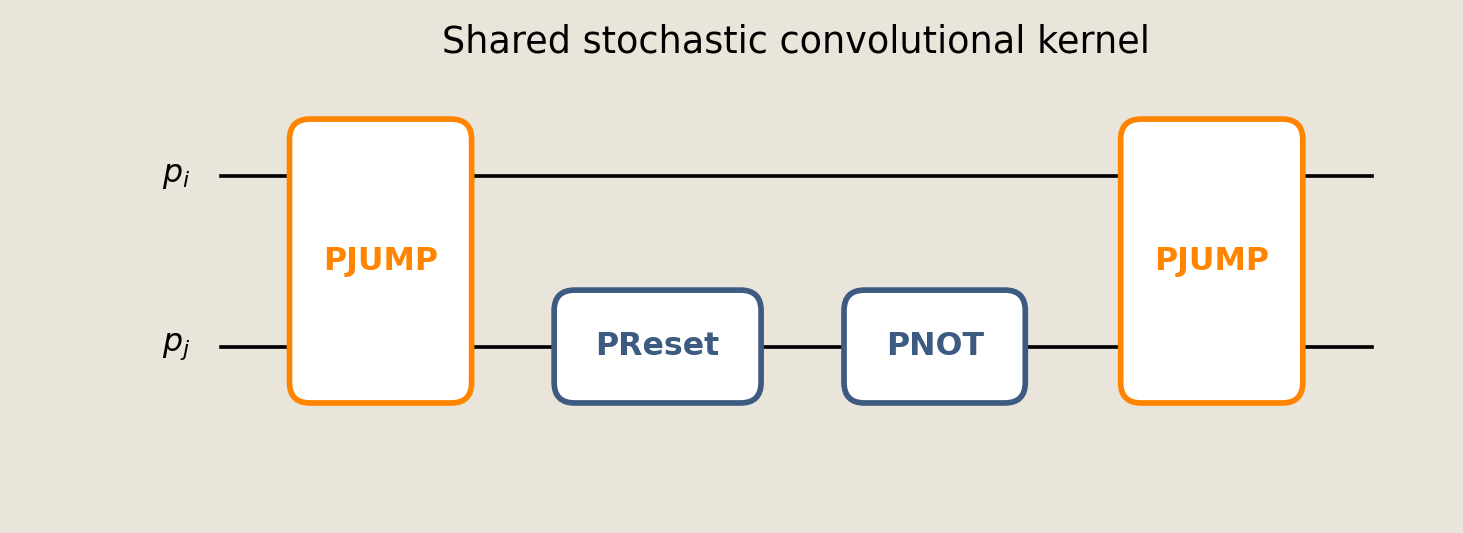

In [12]:
kernel = DiscretePCircuit(circuit.gates[:4])
fig = P_sch.plot_kernel_circuit(kernel)
savefig(fig, "08_scnn_circuit")

The kernel picture says nothing about where that kernel is reused, so we now draw the full `circuit` and show where its five logits appear. We recover the spatial wiring from `circuit` and `param_map` themselves rather than redeclaring it, which means the schematic can only show sharing the circuit actually has.

The 16 pbits sit on the $4\times4$ grid, each horizontal pair receives the same local kernel, and the two-stage `PCNOT` pooling funnels the state into 4 readout sites. Gold and copper distinguish the two `PCNOT` pooling stages.

In [13]:
# Recover the spatial wiring from the circuit + param_map for the schematic.
def _gate_sites(g):
    return [int(v) for v in g.sites]




In [14]:
conv_pairs, _seen = [], set()
col_pool_edges, row_pool_edges = [], []
for g, p in zip(circuit.gates, param_map):
    if p not in (0, 3, 4):
        continue
    s = _gate_sites(g)
    if p == 0 and len(s) == 2:  # PJUMP conv gate -> horizontal pixel pair
        pair = tuple(sorted(s))
        if pair not in _seen:
            _seen.add(pair)
            conv_pairs.append(pair)
    elif p == 3:  # stage-1 column pooling PCNOT
        col_pool_edges.append((s[0], s[1]))
    elif p == 4:  # stage-2 row pooling PCNOT
        row_pool_edges.append((s[0], s[1]))



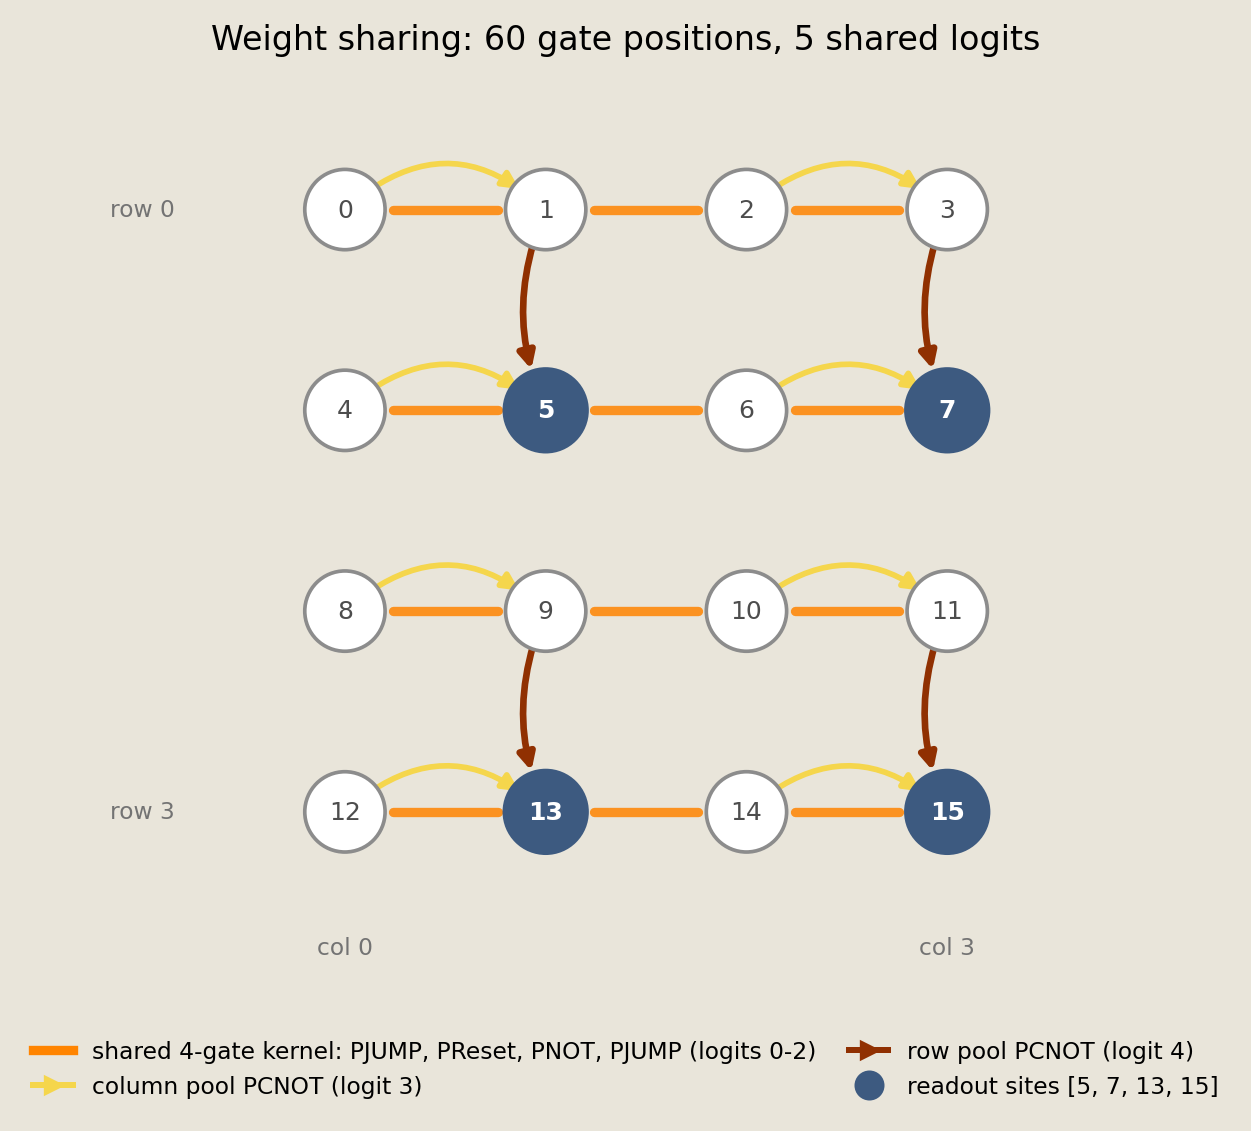

In [15]:
fig = P_sch.plot_weight_sharing_schematic(
    N_SIDE,
    conv_pairs,
    col_pool_edges,
    row_pool_edges,
    readout_sites,
    len(circuit.gates),
    len(np.unique(param_map)),
)
savefig(fig, "08_weight_sharing")

Every gate position drawn with the same line style and color is driven by the same logit, so only five parameter groups are free in the entire layer, and the dark nodes mark the four readout sites the classifier will see.

## Training the kernel

To train through the sampler, we need a derivative that works with samples. A parameter-shift estimator supplies one without differentiating the sampling step itself: it re-runs the circuit with a gate parameter forced to special values, then combines the resulting expectations into the derivative.

`BranchingSimulator` with `diff_method="param_shift_inf"` and `num_samples=256` gives differentiable expected readouts. For a gate $G(\theta)=(1-\sigma(\theta))I+\sigma(\theta)B$, those special values are the two extremes of the logit, so the method evaluates the branches by clamping the gate logit to $-\infty$ and $+\infty$. Those limits force the identity branch and the $B$ branch deterministically.

For a readout $O$, the derivative of the expected readout with respect to the gate logit is

$$
\frac{\mathrm{d}}{\mathrm{d}\theta}\,\mathbb E[O]\;=\;\sigma(\theta)\,\bigl(\mathbb E[O\mid B]-\mathbb E[O]\bigr),
$$

where the $\pm\infty$ clamps supply the branch expectations $\mathbb E[O\mid I]$ and $\mathbb E[O\mid B]$, and $\mathbb E[O]=(1-\sigma(\theta))\,\mathbb E[O\mid I]+\sigma(\theta)\,\mathbb E[O\mid B]$ is the expectation under the current circuit. Each expectation is estimated from samples, which is why the gradient carries Monte Carlo noise and why we probe it with a finite difference later. Unlike the finite-shift quantum rules in [Mitarai et al. (2018)](#ref-mitarai-2018) and [Schuld et al. (2019)](#ref-schuld-2019), this classical stochastic rule evaluates the two deterministic branches directly.


Rebuilding the circuit on every forward pass would repeat work that never changes, so we build the differentiable sampler `sim` once and compile the circuit once into `scnn_template`. Each forward pass then uses [`eqx.tree_at`](https://docs.kidger.site/equinox/api/manipulation/#equinox.tree_at) to swap the current shared logits into that template, which keeps the gate thetas tied to the trainable logits.

In [16]:
sim = BranchingSimulator(diff_method="param_shift_inf", num_samples=256)
# compile the structure-only circuit once; the forward pass swaps in the
# current shared logits with eqx.tree_at instead of rebuilding the circuit.
# num_samples comes from the calling sampler, so this template is reusable by
# the finite-difference sampler too.
scnn_template = sim.build_circuit(circuit, [jnp.zeros((1,)) for _ in circuit.gates])

`SCNN` is where weight sharing becomes an array operation. Indexing the 5 shared logits by `param_map` broadcasts them onto all 60 gate positions, so a gradient arriving at any position accumulates back into its shared logit, and the 4 readout sites are the only features the linear sigmoid classifier ever sees.

In [17]:
class SCNN(eqx.Module):
    gate_logits: jax.Array
    linear: eqx.nn.Linear
    # non-inexact: adam skips structural indices
    _param_map: jax.Array
    _readout_sites_arr: jax.Array

    def __call__(self, x, key, sampler):
        # Broadcast the 5 shared logits onto the 60 physical gate positions.
        full_thetas = self.gate_logits[self._param_map][:, None]
        # Swap the shared logits into the precompiled template instead of
        # rebuilding the circuit; keeps the thetas tied to the trainable logits.
        compiled = eqx.tree_at(lambda c: c.thetas, scnn_template, full_thetas)
        ev = sampler.expval_all(compiled, x, key)
        # The classifier sees only the pooled readout sites.
        features = ev[self._readout_sites_arr]
        return jax.nn.sigmoid(jnp.squeeze(self.linear(features)))

We draw the split once, from `rng` and seed 123, so the same 6 images serve as validation for every epoch and the trace is never disturbed by a shifting split. The cell also prints the validation majority baseline, the accuracy you would get by always predicting whichever class is more common in those 6 images, which is the floor real learning has to clear.

In [18]:
order = rng.permutation(len(patterns))
train_idx, val_idx = order[:24], order[24:]
x_train = jnp.asarray(patterns[train_idx])
y_train = jnp.asarray(labels[train_idx])
x_val = jnp.asarray(patterns[val_idx])
y_val = jnp.asarray(labels[val_idx])
train_n, val_n = len(x_train), len(x_val)
assert train_n == 24 and val_n == 6
val_class_counts = np.bincount(np.asarray(y_val, dtype=np.int32), minlength=2)
val_majority_count = int(val_class_counts.max())
val_majority_acc = val_majority_count / val_n
print(f"train / validation split (seed {SEED}): {train_n} / {val_n}")
print(
    f"validation majority baseline: {val_majority_count} of {val_n} "
    f"({val_majority_acc:.0%})"
)

train / validation split (seed 123): 24 / 6
validation majority baseline: 4 of 6 (67%)


In [19]:
model = SCNN(
    gate_logits=initial_gate_logits,
    linear=eqx.nn.Linear(len(readout_sites), 1, key=jax.random.key(SEED)),
    _param_map=jnp.asarray(param_map),
    _readout_sites_arr=jnp.asarray(readout_sites),
)

Adam at a learning rate of 5e-2 does the updating, and `eqx.filter(model, eqx.is_inexact_array)` decides what it may touch: the 5 shared logits and the linear head, but not the integer `param_map` and readout indices, which are structure rather than parameters.

In [20]:
optimizer = optax.adam(5e-2)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

The objective is ordinary binary cross-entropy over the batch, with predictions clipped away from 0 and 1 so the logarithm stays finite. Wrapping `bce_loss` in `eqx.filter_value_and_grad` is what pulls the parameter-shift gradient back through the sampler, so `loss_fn` returns the loss and the gradient with respect to the shared logits together, and the undecorated `bce_loss` stays available because the finite-difference check later needs loss values only.

Two thin wrappers finish the loop: `train_step` takes one Adam step, computing the loss and gradients and then applying the updates, and `evaluate` returns validation loss and accuracy for each epoch without changing the parameters.

In [21]:
def bce_loss(model, x_batch, y_batch, key, sampler=sim):
    # Give each image its own random key for independent sampler noise.
    keys = jax.random.split(key, len(x_batch))
    preds = jax.vmap(lambda xi, ki: model(xi, ki, sampler))(x_batch, keys)
    preds = jnp.clip(preds, 1e-6, 1.0 - 1e-6)
    return jnp.mean(
        -(y_batch * jnp.log(preds) + (1.0 - y_batch) * jnp.log(1.0 - preds))
    )


# undecorated bce_loss is reused by the finite-difference probe (loss only);
# this wrapper adds the param-shift gradient for training and the analytic check
loss_fn = eqx.filter_value_and_grad(bce_loss)

In [22]:
@eqx.filter_jit
def train_step(model, opt_state, x_batch, y_batch, key):
    loss, grads = loss_fn(model, x_batch, y_batch, key)
    updates, opt_state = optimizer.update(
        grads, opt_state, eqx.filter(model, eqx.is_inexact_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

In [23]:
@eqx.filter_jit
def evaluate(model, x_batch, y_batch, key, sampler=sim):
    keys = jax.random.split(key, len(x_batch))
    preds = jax.vmap(lambda xi, ki: model(xi, ki, sampler))(x_batch, keys)
    preds = jnp.clip(preds, 1e-6, 1.0 - 1e-6)
    loss = jnp.mean(
        -(y_batch * jnp.log(preds) + (1.0 - y_batch) * jnp.log(1.0 - preds))
    )
    acc = jnp.mean((preds >= 0.5) == y_batch)
    return loss, acc

Training runs 90 full-batch epochs, and the one subtlety is randomness. `fit_model` splits the seed-123 key once per epoch so the sampler noise in the training step is independent of the noise in the evaluation, which keeps the recorded six-example validation trace from echoing the training samples. We then run it and report the final validation loss and accuracy for n=6.

In [24]:
def fit_model(model, opt_state, x_train, y_train, x_val, y_val):
    loss_history, acc_history = [], []
    key = jax.random.key(SEED)
    for epoch in range(90):
        # Split once per epoch so training and validation use independent samples.
        key, train_key, eval_key = jax.random.split(key, 3)
        model, opt_state, _ = train_step(model, opt_state, x_train, y_train, train_key)
        val_loss, val_acc = evaluate(model, x_val, y_val, eval_key)
        # keep device arrays; convert the whole trace to host once after training
        loss_history.append(val_loss)
        acc_history.append(val_acc)
    return model, opt_state, np.asarray(loss_history), np.asarray(acc_history)

In [25]:
model, opt_state, loss_history, acc_history = fit_model(
    model, opt_state, x_train, y_train, x_val, y_val
)

print(f"final validation loss (n={val_n}):     {loss_history[-1]:.4f}")
print(f"final validation accuracy (n={val_n}): {acc_history[-1]:.2%}")

final validation loss (n=6):     0.0944
final validation accuracy (n=6): 100.00%


For this fixed seed, the six-item validation set ends at 100% accuracy, which is a coarser claim than it sounds, because with six examples accuracy can only change in increments of $1/6$.

### Gradient check

A gradient that flows and a gradient that is correct are different things, and so far we have only seen the first. So we test one shared `PJUMP` logit (`LOGIT_IDX = 0`), whose `param_shift_inf` gradient should agree with a finite-difference estimate up to Monte Carlo noise, the random scatter that comes from estimating expectations with finitely many samples. In the next cells we compute the analytic gradient on one small batch of 4 bars and 4 stripes, probe the same logit numerically, and report the relative error. The check covers only one of the five logits, at 30% tolerance, so it's evidence that the differentiable path is wired correctly rather than a verification of all five.

In [26]:
LOGIT_IDX = 0
bars_idx = np.where(labels == 0)[0][:4]
stripes_idx = np.where(labels == 1)[0][:4]
batch_x = jnp.asarray(patterns[np.concatenate([bars_idx, stripes_idx])])
batch_y = jnp.asarray(labels[np.concatenate([bars_idx, stripes_idx])])
key_grad = jax.random.key(SEED + 7)

_, grads = loss_fn(model, batch_x, batch_y, key_grad)
g_analytic = float(grads.gate_logits[LOGIT_IDX])

The reference is a central finite difference on the same logit, a cruder estimate but one that never runs the parameter-shift code, so agreement between the two is real evidence rather than a tautology. `fd_grad` builds a fresh `BranchingSimulator` at the requested sample count for each probe, because the cure for a noisy comparison is more samples.

In [27]:
def fd_grad(m, epsilon, n_samples):
    fd_sampler = BranchingSimulator(diff_method="param_shift_inf", num_samples=n_samples)
    m_plus = eqx.tree_at(
        lambda mod: mod.gate_logits,
        m,
        m.gate_logits.at[LOGIT_IDX].add(epsilon),
    )
    m_minus = eqx.tree_at(
        lambda mod: mod.gate_logits,
        m,
        m.gate_logits.at[LOGIT_IDX].add(-epsilon),
    )
    # Reuse key_grad on both sides so only the logit perturbation changes.
    # bce_loss (undecorated) computes loss only, so no param-shift gradient is
    # wasted on each finite-difference evaluation.
    loss_plus = float(bce_loss(m_plus, batch_x, batch_y, key_grad, fd_sampler))
    loss_minus = float(bce_loss(m_minus, batch_x, batch_y, key_grad, fd_sampler))
    return (loss_plus - loss_minus) / (2.0 * epsilon)

Now we compare the two numbers. The finite difference is itself a sample estimate, so a single probe can fail on noise alone, which is why we walk a ladder of probes at 256, 1024, and 2048 samples per side and stop at the first relative error under `REL_ERR_TOL = 0.30`. The assertion that follows uses that same tolerance, so a genuinely broken gradient path fails the notebook instead of passing quietly.

In [28]:
print(f"analytic (param-shift, logit {LOGIT_IDX}): {g_analytic:.6f}")
REL_ERR_TOL = 0.30
FD_PROBES = [(256, 0.05), (1024, 0.05), (2048, 0.10)]
g_fd, rel_err = None, np.inf
for i, (n_samples, eps) in enumerate(FD_PROBES):
    g_fd = fd_grad(model, eps, n_samples)
    rel_err = abs(g_analytic - g_fd) / (abs(g_fd) + 1e-6)
    label = "finite-diff" if i == 0 else "retry finite-diff"
    print(f"{label} (eps={eps}, {n_samples} samples/side): {g_fd:.6f}")
    print(f"relative error: {rel_err:.4f}")
    if rel_err < REL_ERR_TOL:
        break

analytic (param-shift, logit 0): -0.013853
finite-diff (eps=0.05, 256 samples/side): -0.016632
relative error: 0.1671


In [29]:
assert (
    rel_err < REL_ERR_TOL
), f"gradient check failed: analytic={g_analytic}, fd={g_fd}, rel_err={rel_err}"
print(f"gradient check passed (rel_err < {REL_ERR_TOL:.2f})")

gradient check passed (rel_err < 0.30)


## Kernel parameter shifts

A model can reach good accuracy by training the linear head alone and leaving the kernel where it started, so accuracy on its own doesn't tell us the gradient reached the shared gates. The table lists the initial logit, the trained logit, and the shift for each shared gate, and a nonzero shift is what shows that the gradient reached the shared kernel. The cell asserts that the movement is real: an L2 shift above 1e-3, a maximum absolute shift above 0.05, and a final accuracy of at least 0.75.

In [30]:
gate_names = ["PJUMP", "PReset", "PNOT", "PCNOT-col", "PCNOT-row"]

print(f"{'gate':<12}  {'init logit':>10}  {'trained logit':>13}  {'shift':>8}")
print("-" * 48)
for name, init_l, fin_l in zip(
    gate_names, initial_gate_logits.tolist(), model.gate_logits.tolist()
):
    print(f"{name:<12}  {init_l:>10.4f}  {fin_l:>13.4f}  {fin_l - init_l:>+8.4f}")

gate_shift = float(jnp.linalg.norm(model.gate_logits - initial_gate_logits))
max_abs_shift = float(jnp.max(jnp.abs(model.gate_logits - initial_gate_logits)))

print(f"\nL2 shift: {gate_shift:.4f}    max |shift|: {max_abs_shift:.4f}")

assert acc_history[-1] >= 0.75, f"accuracy {acc_history[-1]:.2%} below 0.75 threshold"
assert gate_shift > 1e-3, "gate logits did not move during training"
assert (
    max_abs_shift > 0.05
), f"max logit shift {max_abs_shift:.4f} < 0.05, gradient did not reach the kernel"
print("\nall checks passed")
print("  acc_history[-1] >= 0.75")
print("  gate logit L2 shift > 1e-3")
print("  max |gate logit shift| > 0.05")

gate          init logit  trained logit     shift
------------------------------------------------
PJUMP            -0.6633         0.1162   +0.7795
PReset           -2.4423        -5.6673   -3.2249
PNOT             -2.7515        -6.2989   -3.5474
PCNOT-col         0.2007         3.6767   +3.4760
PCNOT-row         0.4055        -2.8612   -3.2667



L2 shift: 6.8078    max |shift|: 3.5474

all checks passed
  acc_history[-1] >= 0.75
  gate logit L2 shift > 1e-3
  max |gate logit shift| > 0.05


## Training curve

Finally we look at what the optimizer was scored on: validation BCE and validation accuracy on the same six examples after every epoch. Accuracy moves in $1/6$ increments, so that panel climbs as a staircase, and the 67% line is the seed-specific validation majority baseline a trivial classifier would already reach. The inset encodes black pixels as 1 and white pixels as 0. Because those six images are scored every epoch rather than held back, this repeated validation trace is an optimization diagnostic, not an estimate from an untouched test set.

In [31]:
# Pick a visually informative bar pattern: top two rows black, bottom two white.
bar_idx = next(
    i
    for i, (p, l) in enumerate(zip(patterns, labels))
    if l == 0 and tuple(p.reshape(N_SIDE, N_SIDE)[:, 0]) == (1, 1, 0, 0)
)
bar_image = patterns[bar_idx].reshape(N_SIDE, N_SIDE)



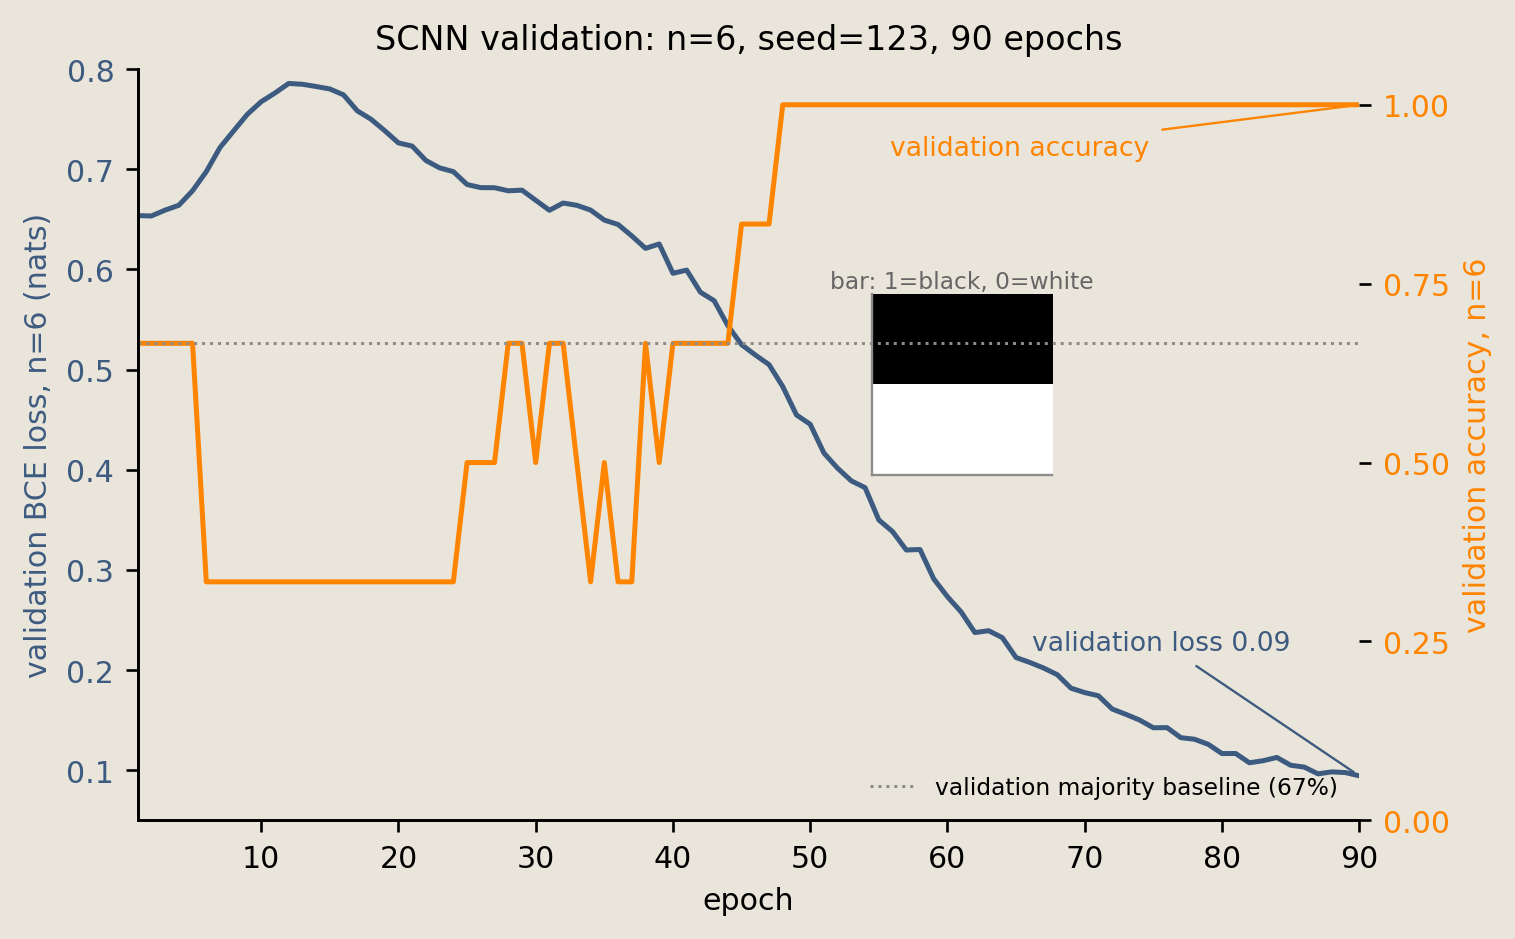

final validation accuracy: 100.00%
gate logit L2 shift:       6.8078
max |gate logit| shift:    3.5474


In [32]:
fig = P_train.plot_training_curve(
    loss_history,
    acc_history,
    bar_image,
    validation_n=val_n,
    majority_baseline=val_majority_acc,
    title=f"SCNN validation: n={val_n}, seed={SEED}, 90 epochs",
)
savefig(fig, "08_scnn_training")
print(f"final validation accuracy: {acc_history[-1]:.2%}")
print(f"gate logit L2 shift:       {gate_shift:.4f}")
print(f"max |gate logit| shift:    {max_abs_shift:.4f}")

## Conclusion

You have now built a stochastic convolution layer over 16 p-bits, one per pixel, that classifies bars-and-stripes images by taking gradients through the sampler.

- A four-gate kernel (`PJUMP`, `PReset`, `PNOT`, `PJUMP`) runs on every horizontal adjacent pixel pair, with `PCNOT` pooling down to 4 readout sites.
- `param_map` ties all 60 physical gates to 5 shared logits, giving a convolution-like horizontal stencil rather than an exact shift symmetry.
- `param_shift_inf` returns a sample-based gradient through the sampler, and `optax.adam` trains the shared logits and a linear head together.
- A finite-difference probe sanity-checks one shared `PJUMP` logit against the `param_shift_inf` gradient (one logit, one small batch, 30% tolerance), which gives evidence that the sampler path is differentiable while stopping short of a full multi-logit verification.

[`09_stochastic_graph_networks.ipynb`](09_stochastic_graph_networks.ipynb) shows another stochastic-circuit learning pattern with shared parameters.

## References

1. <span id="ref-mitarai-2018"></span>Mitarai, K., Negoro, M., Kitagawa, M., Fujii, K. 2018. [*Quantum circuit learning*](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.032309). Phys. Rev. A 98, 032309.
2. <span id="ref-schuld-2019"></span>Schuld, M., Bergholm, V., Gogolin, C., Izaac, J., Killoran, N. 2019. [*Evaluating analytic gradients on quantum hardware*](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.99.032331). Phys. Rev. A 99, 032331.